In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [4]:
# Vocabulary size
vocab_size = 10000

# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


# Data Preprocessing

In [6]:
# Maximum review length
maxlen = 200

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


# RNN Model

In [19]:
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

rnn_model.build(input_shape=(None, maxlen))
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 200, 32)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

# Train RNN

In [9]:
rnn_history = rnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6780 - loss: 0.5806 - val_accuracy: 0.7460 - val_loss: 0.5177
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.8163 - loss: 0.4245 - val_accuracy: 0.8026 - val_loss: 0.4454
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.8806 - loss: 0.2989 - val_accuracy: 0.8272 - val_loss: 0.4191


# Evaluate RNN

In [10]:
rnn_loss, rnn_acc = rnn_model.evaluate(x_test, y_test)

print("RNN Test Accuracy:", rnn_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8253 - loss: 0.4149
RNN Test Accuracy: 0.8253200054168701


# LSTM Model

In [12]:
lstm_model = Sequential([
    Embedding(vocab_size, 32),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train LSTM

In [15]:
lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.7566 - loss: 0.4830 - val_accuracy: 0.8616 - val_loss: 0.3337
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9002 - loss: 0.2598 - val_accuracy: 0.8764 - val_loss: 0.3209
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9270 - loss: 0.1987 - val_accuracy: 0.8752 - val_loss: 0.3493


# Evaluate LSTM

In [16]:
lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test)

print("LSTM Test Accuracy:", lstm_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8575 - loss: 0.3918
LSTM Test Accuracy: 0.857479989528656


# Compare Models

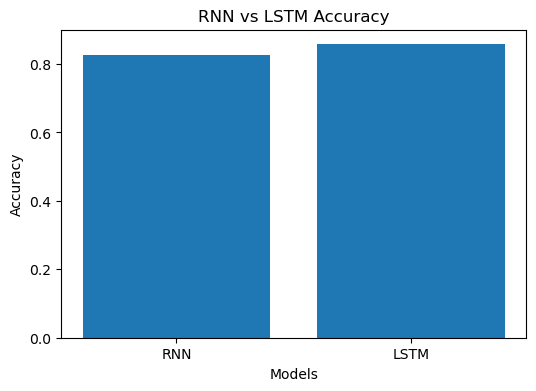

In [17]:
models = ['RNN', 'LSTM']
accuracies = [rnn_acc, lstm_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM Accuracy")
plt.show()

# Plot Training Accuracy

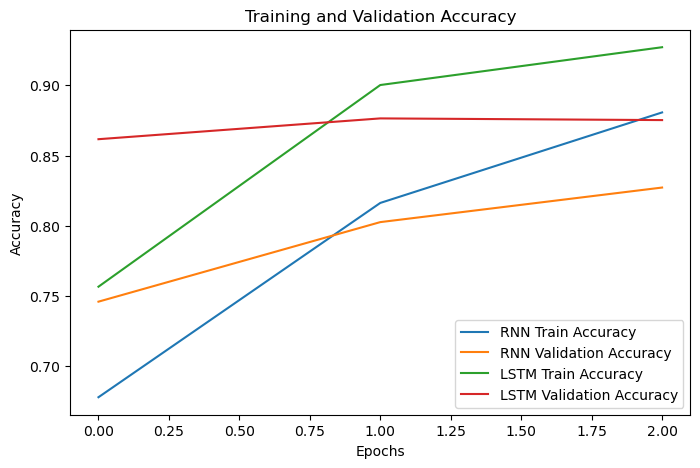

In [18]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Validation Accuracy')

plt.plot(lstm_history.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()